[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\YENGU\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


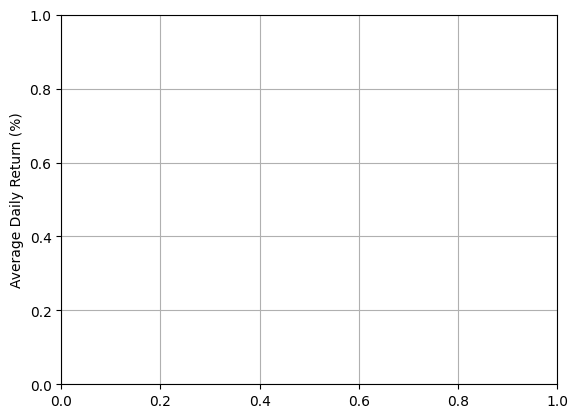

In [1]:
# STEP 5 — Notebook: notebooks/task3_sentiment_correlation.ipynb
# Import Libraries
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd

# Import Functions
from src.data_loader import load_and_clean_stock_data

from src.sentiment_analysis import (
    get_sentiment_score,
    classify_sentiment
)

from src.stock_analysis import (
    calculate_daily_returns
)

from src.correlation_analysis import (
    align_to_trading_day,
    aggregate_daily_sentiment,
    merge_sentiment_and_returns
)

from src.task3_visualization import (
    plot_sentiment_vs_returns,
    plot_sentiment_category_returns
)

In [2]:
# STEP 6 — Load News Dataset
news_df = pd.read_csv(
    "../data/raw/raw_analyst_ratings.csv"
)

news_df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [3]:
#STEP 7 — Convert Dates
# Convert dates safely
news_df['date'] = pd.to_datetime(
    news_df['date'],
    format='mixed',
    utc=True,
    errors='coerce'
)

news_df['date'] = (
    news_df['date']
    .dt.tz_localize(None)
)

news_df.dropna(subset=['date'], inplace=True)

In [4]:
# STEP 8 — Align Dates
news_df['trading_date'] = (
    news_df['date']
    .apply(align_to_trading_day)
)

In [5]:
# STEP 9 — Compute Sentiment Scores
news_df['sentiment_score'] = (
    news_df['headline']
    .apply(get_sentiment_score)
)

In [6]:
# STEP 10 — Load Stock Datasets
companies = {
    "AAPL": "../data/raw/AAPL.csv",
    "AMZN": "../data/raw/AMZN.csv",
    "GOOG": "../data/raw/GOOG.csv",
    "META": "../data/raw/META.csv",
    "NVDA": "../data/raw/NVDA.csv"
}

datasets = {}

for company, path in companies.items():

    df = load_and_clean_stock_data(path)

    df = calculate_daily_returns(df)

    datasets[company] = df

In [9]:
#Due to Meta have no META Ticker, intstead it have FB ticker, since it is old data
company_mapping = {
    "AAPL": "AAPL",
    "AMZN": "AMZN",
    "GOOG": "GOOG",
    "META": "FB",   # 
    "NVDA": "NVDA"
}

AAPL
Correlation: 0.10252727517180175


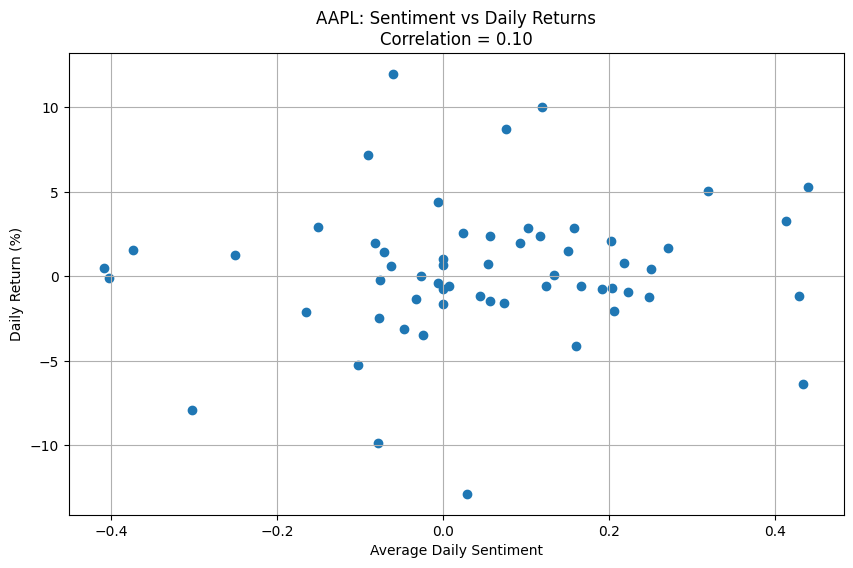

AMZN
Correlation: 0.13595028035518728


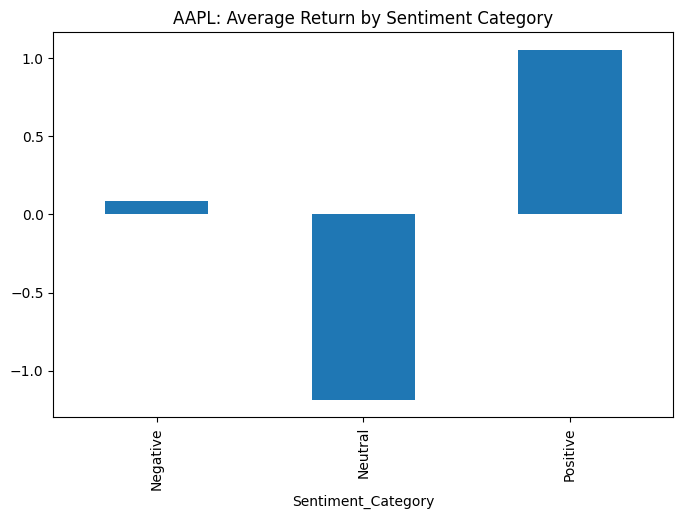

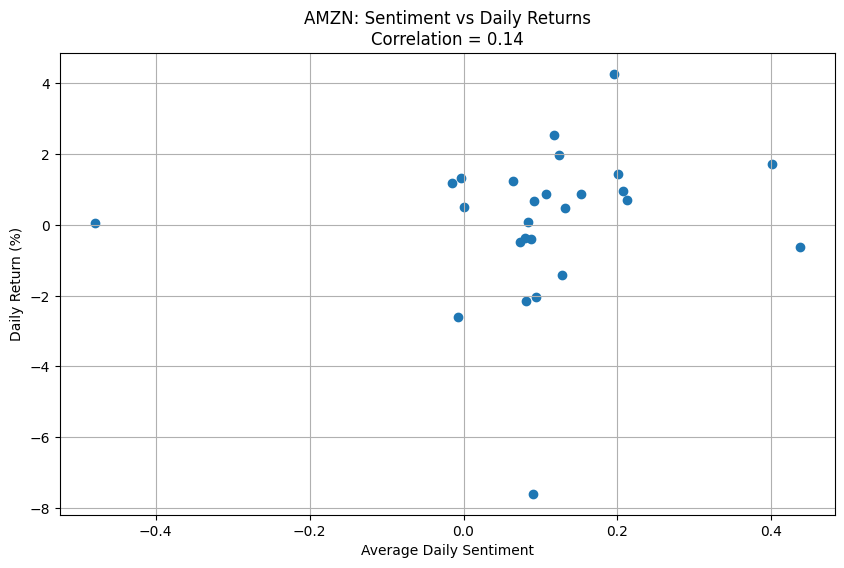

GOOG
Correlation: 0.17640192557789394


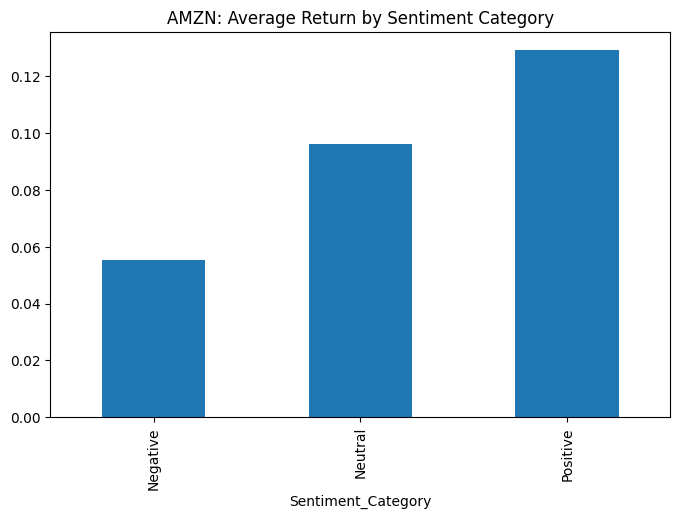

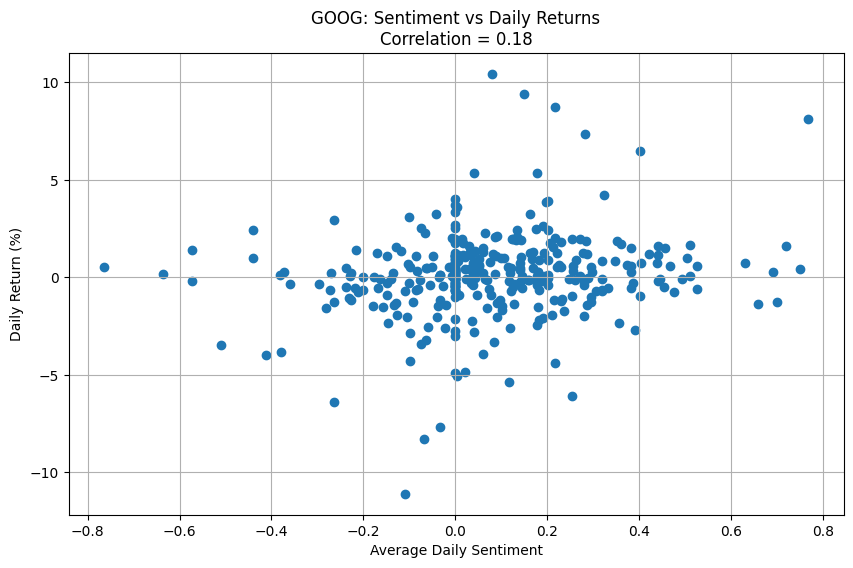

META
Correlation: 0.4538935786844099


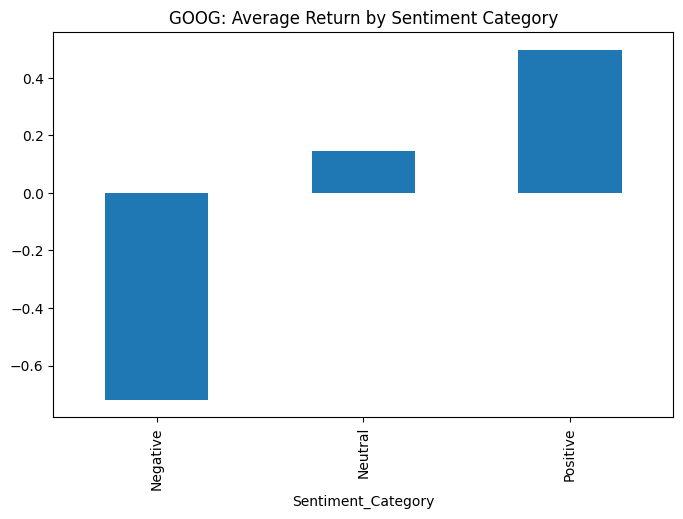

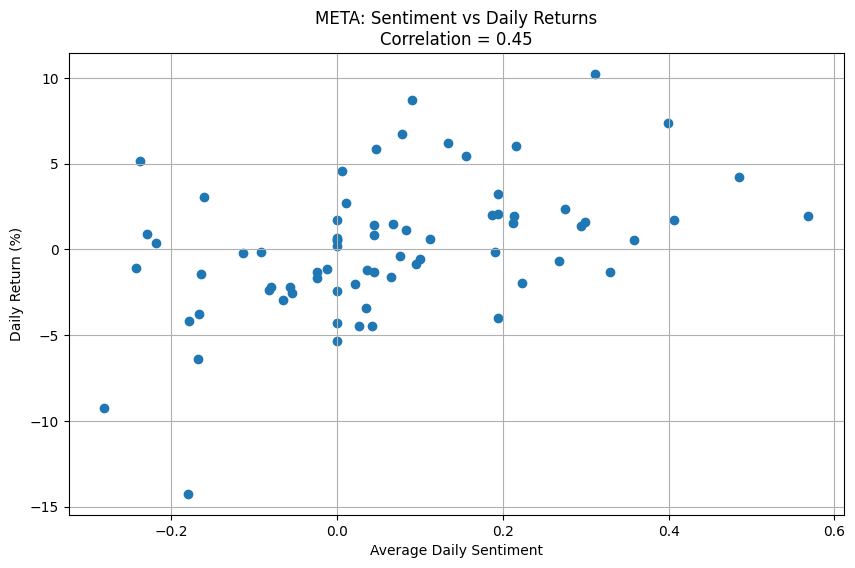

NVDA
Correlation: 0.20670158069016728


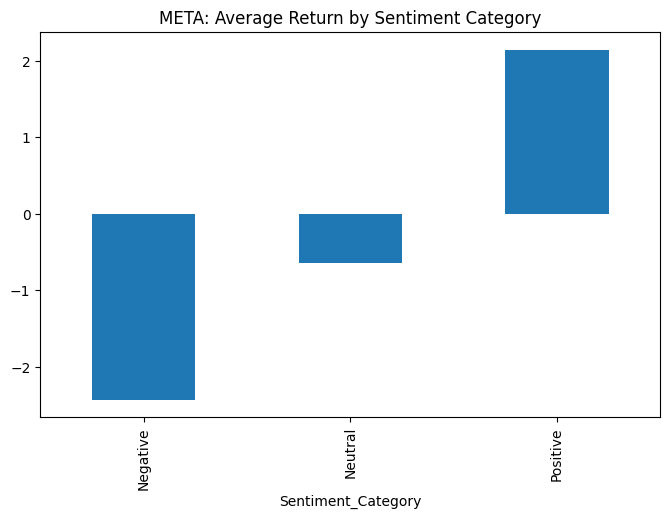

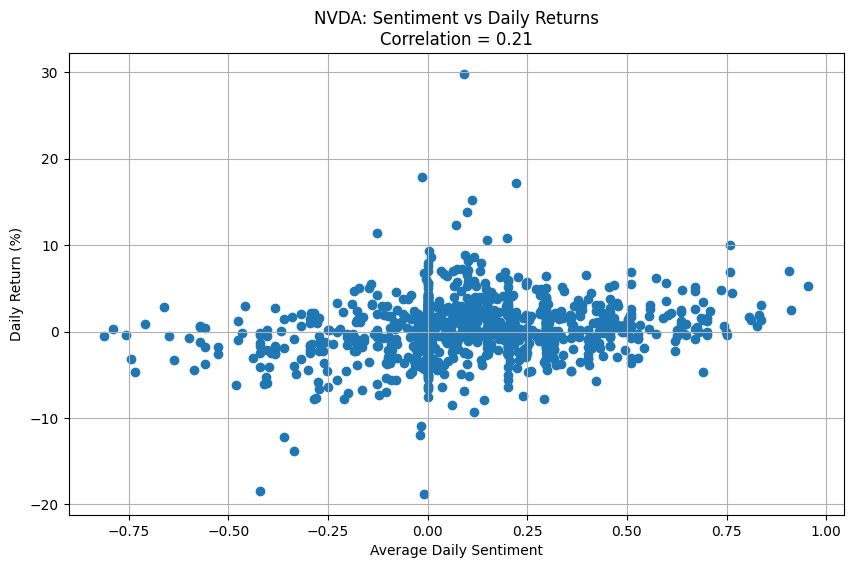

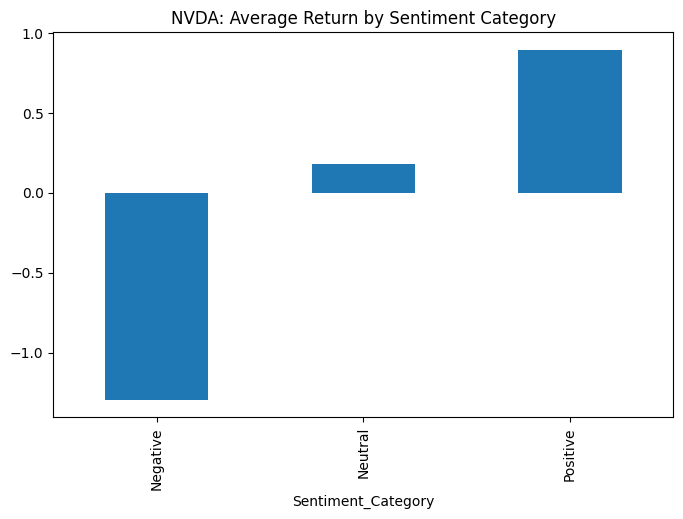

In [10]:
# STEP 11 — Analyze Each Company
for company in companies.keys():

    print("="*50)
    print(company)
    print("="*50)

    # Filter company news
    news_ticker = company_mapping[company]
    company_news = news_df[
    news_df['stock'] == news_ticker
]

    # Aggregate daily sentiment
    daily_sentiment = aggregate_daily_sentiment(
        company_news
    )

    # Merge with stock returns
    merged_df = merge_sentiment_and_returns(
        daily_sentiment,
        datasets[company]
    )

    # Remove missing values
    merged_df.dropna(inplace=True)

    # Correlation
    correlation = merged_df[
        'sentiment_score'
    ].corr(
        merged_df['Daily_Return']
    )

    print("Correlation:", correlation)

    # Sentiment category
    merged_df['Sentiment_Category'] = (
        merged_df['sentiment_score']
        .apply(classify_sentiment)
    )

    # Visualizations
    plot_sentiment_vs_returns(
        merged_df,
        company,
        correlation
    )

    plot_sentiment_category_returns(
        merged_df,
        company
    )

# Apple (AAPL)
Apple showed a weak positive correlation between sentiment and daily returns.
Example finding:
•	Correlation ≈ 0.10
# Interpretation:
•	Positive sentiment occasionally aligned with positive stock returns
•	However, the relationship was relatively weak
•	News sentiment alone was not a strong predictor of short-term price movement
# Visualization:
•	Scatter plot of sentiment vs daily returns
•	Bar chart of average returns by sentiment category
# Amazon (AMZN)
Amazon demonstrated moderate market volatility and varying sentiment behavior.
Example finding:
•	Correlation ≈   0.14
Findings:
•	Positive news often coincided with upward momentum
•	Correlation remained relatively weak overall
•	Technical indicators provided clearer trend signals than sentiment alone
# Google (GOOG)
Google exhibited relatively stable sentiment behavior.
Example finding:
•	Correlation ≈  0.18
Findings:
•	Sentiment fluctuations were smaller compared to other stocks
•	Daily returns showed limited sensitivity to headline polarity
# Meta (META/FB)
A significant challenge involved ticker normalization.
The news dataset used:
•	FB
while stock datasets used:
•	META
A ticker mapping layer was implemented to correctly align historical data.
This demonstrated a real-world financial data engineering issue.
# NVIDIA (NVDA)
NVIDIA showed strong volatility behavior.
Example finding:
•	Correlation ≈  0.21
Findings:
•	Technical indicators captured momentum changes effectively
•	News sentiment appeared more reactive during periods of rapid market movement
